# S1.0: axis-safe frozen synthetic benchmark плеврального скольжения

Этот notebook **не запускает и не настраивает регистрацию**. Он читает batch-артефакты,
созданные командой `breathgeom registration sliding-synthetic`, проверяет checksums и
визуализирует заранее зафиксированный algorithmic gate `sliding-phantom-v2.1-axis-safe`.

Исторический результат на v2.0 помечен как superseded: его азимутальное поле сохраняло
почти полную амплитуду у оси, где направление не определено. Здесь алгоритм S1.0 и
пороги не менялись; изменена только версия ground truth.

S1 получает только fixed/moving изображения и маски. Аналитические поля используются
только оценщиком после завершения регистрации. PASS здесь ещё не заменил бы реальные
Gate 1L/1B; FAIL блокирует real-pair benchmark и парные карты.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

candidate = Path.cwd().resolve()
REPO_ROOT = next(
    (path for path in (candidate, *candidate.parents) if (path / "pyproject.toml").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Не найден корень репозитория")

RESULTS = REPO_ROOT / "results/sliding_s1_v0_phantom_v21"
manifest_path = RESULTS / "manifest.json"
summary_path = RESULTS / "summary.csv"
if not manifest_path.is_file() or not summary_path.is_file():
    raise RuntimeError(
        "Нет batch-артефактов. Сначала выполните: "
        "breathgeom registration sliding-synthetic"
    )

## Provenance и целостность

Manifest фиксирует версии suite/S1, commit базового вычислительного кода, параметры gate
и SHA-256 каждого внешнего артефакта. В notebook не встраиваются локальные абсолютные пути.

In [2]:
def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()


manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
assert sha256(summary_path) == manifest["summary_sha256"]
for filename, expected in manifest["field_sha256"].items():
    assert sha256(RESULTS / filename) == expected

provenance = pd.DataFrame(
    [
        {"Параметр": "suite_version", "Значение": manifest["suite_version"]},
        {"Параметр": "s1_version", "Значение": manifest["s1_version"]},
        {"Параметр": "code_version", "Значение": manifest["code_version"]},
        {"Параметр": "suite_sha256", "Значение": manifest["suite_config"]["sha256"]},
        {"Параметр": "s1_config_sha256", "Значение": manifest["s1_config"]["sha256"]},
        {"Параметр": "artifact_usage", "Значение": manifest["usage"]},
        {"Параметр": "checksum_verdict", "Значение": "PASS"},
    ]
)
display(provenance)

,Параметр,Значение
0,suite_version,sliding-phantom-v2.1-axis-safe
1,s1_version,s1.0
2,code_version,96d422a1637ccee33cb88165fffdd53539cbd2b9
3,suite_sha256,B4BF5CAB3855DCCE1376D658D2D5F41C20E01BD5D8D19F...
4,s1_config_sha256,D4AD389C19803FC3158EFAA6C1A7B35890E524581A4DCD...
5,artifact_usage,synthetic_diagnostic_ONLY
6,checksum_verdict,PASS


## Subject-level результаты frozen suite

Единица решения — один synthetic case, не воксель. Полный gate требует одновременного
прохождения endpoint error лёгкого и стенки, normal contact, slip и regional topology.
Сравнение с v2.0 ниже диагностическое: suite изменился, поэтому дельта не является
улучшением алгоритма.

In [3]:
summary = pd.read_csv(summary_path)
summary["gate_reasons"] = summary["gate_reasons"].fillna("")
columns = [
    "case_id",
    "spacing_mm",
    "normal_motion_truth_mm",
    "tangential_slip_truth_mm",
    "endpoint_p95_limit_mm",
    "lung_field_p95_mm",
    "body_field_p95_mm",
    "normal_mismatch_p95_mm",
    "tangential_slip_median_mm",
    "lung_jacobian_p01",
    "body_jacobian_p01",
    "gate_pass",
    "gate_reasons",
]
display(summary[columns].round(3))

gate_matrix = pd.DataFrame(
    {
        "lung field": summary["lung_field_p95_mm"] <= summary["endpoint_p95_limit_mm"],
        "body field": summary["body_field_p95_mm"] <= summary["endpoint_p95_limit_mm"],
        "normal contact": summary["normal_mismatch_p95_mm"]
        <= manifest["gate"]["normal_mismatch_p95_max_mm"],
        "tangential slip": summary["tangential_slip_error_mm"]
        <= manifest["gate"]["tangential_slip_error_max_mm"],
        "lung topology": (
            (summary["lung_jacobian_p01"] >= manifest["gate"]["jacobian_p01_min"])
            & (summary["lung_nonpositive_jacobian_fraction"] == 0)
        ),
        "body topology": (
            (summary["body_jacobian_p01"] >= manifest["gate"]["jacobian_p01_min"])
            & (summary["body_nonpositive_jacobian_fraction"] == 0)
        ),
    },
)
gate_matrix.index = summary["case_id"]
display(gate_matrix)

legacy_summary_path = REPO_ROOT / "results/sliding_s1_v0/summary.csv"
if legacy_summary_path.is_file():
    legacy = pd.read_csv(legacy_summary_path)
    comparison = legacy[[
        "case_id",
        "lung_field_p95_mm",
        "tangential_slip_median_mm",
    ]].merge(
        summary[[
            "case_id",
            "lung_field_p95_mm",
            "tangential_slip_median_mm",
        ]],
        on="case_id",
        suffixes=("_v20_superseded", "_v21_axis_safe"),
    )
    display(comparison.round(3))

,case_id,spacing_mm,normal_motion_truth_mm,tangential_slip_truth_mm,endpoint_p95_limit_mm,lung_field_p95_mm,body_field_p95_mm,normal_mismatch_p95_mm,tangential_slip_median_mm,lung_jacobian_p01,body_jacobian_p01,gate_pass,gate_reasons
0,nominal_1mm,1.0x1.0x1.0,3.0,4.0,1.50,1.296,0.810,0.066,3.358,0.866,0.851,True,
1,shallow_1mm,1.0x1.0x1.0,1.5,2.0,1.50,1.065,0.745,0.041,1.876,0.733,0.912,True,
2,deep_anisotropic,1.25x1.25x1.5,4.5,6.0,2.25,3.706,1.165,0.218,3.213,1.174,0.869,False,lung_field_p95;tangential_slip


,lung field,body field,normal contact,tangential slip,lung topology,body topology
case_id,,,,,,
nominal_1mm,True,True,True,True,True,True
shallow_1mm,True,True,True,True,True,True
deep_anisotropic,False,True,True,False,True,True


,case_id,lung_field_p95_mm_v20_superseded,tangential_slip_median_mm_v20_superseded,lung_field_p95_mm_v21_axis_safe,tangential_slip_median_mm_v21_axis_safe
0,nominal_1mm,1.587,3.706,1.296,3.358
1,shallow_1mm,1.146,2.055,1.065,1.876
2,deep_anisotropic,4.138,4.002,3.706,3.213


## Где именно S1.0 проходит и проваливается

Порог endpoint зависит от максимального размера вокселя. Slip сравнивается с известной
амплитудой каждого случая. Отдельно показан эффект normal-only coupling.

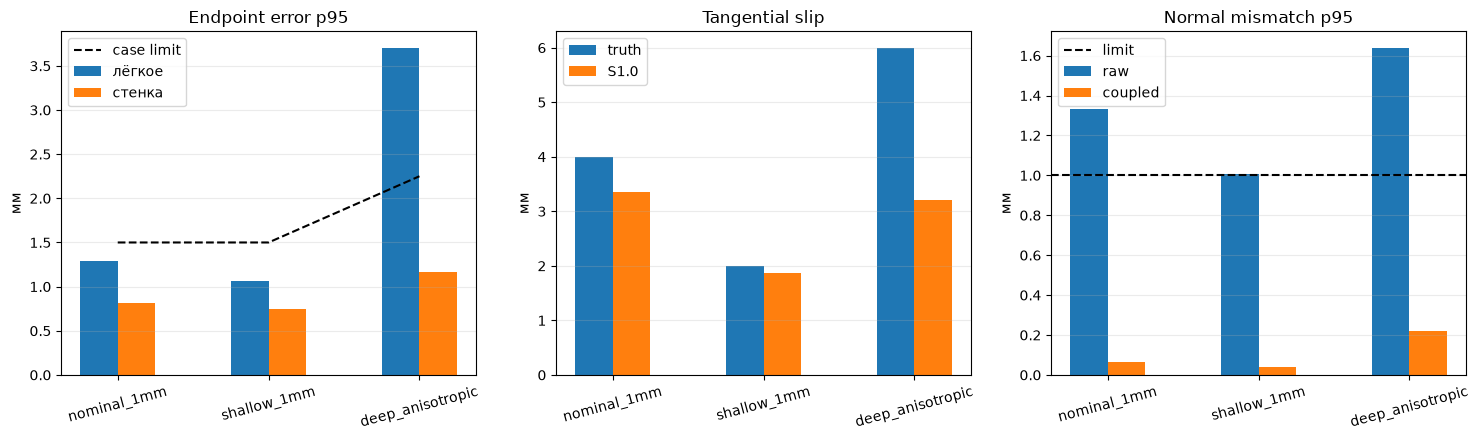

In [4]:
labels = summary["case_id"].tolist()
x = np.arange(len(summary))
width = 0.25
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].bar(x - width / 2, summary["lung_field_p95_mm"], width, label="лёгкое")
axes[0].bar(x + width / 2, summary["body_field_p95_mm"], width, label="стенка")
axes[0].plot(x, summary["endpoint_p95_limit_mm"], "k--", label="case limit")
axes[0].set_title("Endpoint error p95")
axes[0].set_ylabel("мм")
axes[0].legend()

axes[1].bar(x - width / 2, summary["tangential_slip_truth_mm"], width, label="truth")
axes[1].bar(x + width / 2, summary["tangential_slip_median_mm"], width, label="S1.0")
axes[1].set_title("Tangential slip")
axes[1].set_ylabel("мм")
axes[1].legend()

axes[2].bar(x - width / 2, summary["raw_normal_mismatch_p95_mm"], width, label="raw")
axes[2].bar(x + width / 2, summary["normal_mismatch_p95_mm"], width, label="coupled")
axes[2].axhline(
    manifest["gate"]["normal_mismatch_p95_max_mm"],
    color="black",
    linestyle="--",
    label="limit",
)
axes[2].set_title("Normal mismatch p95")
axes[2].set_ylabel("мм")
axes[2].legend()

for ax in axes:
    ax.set_xticks(x, labels, rotation=15)
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Пространственная локализация ошибки

Карты ниже показывают ошибку вектора, а не intensity residual. Цветовая шкала одинакова
для truth/estimate сравнения внутри каждого случая. Таблица делит лёгкое на три части
по локальной оси RAS+ z и проверяет, осталась ли ошибка только у исправленных полюсов.
Данные полностью synthetic; строки таблицы — диагностика внутри case, а не независимые
статистические наблюдения.

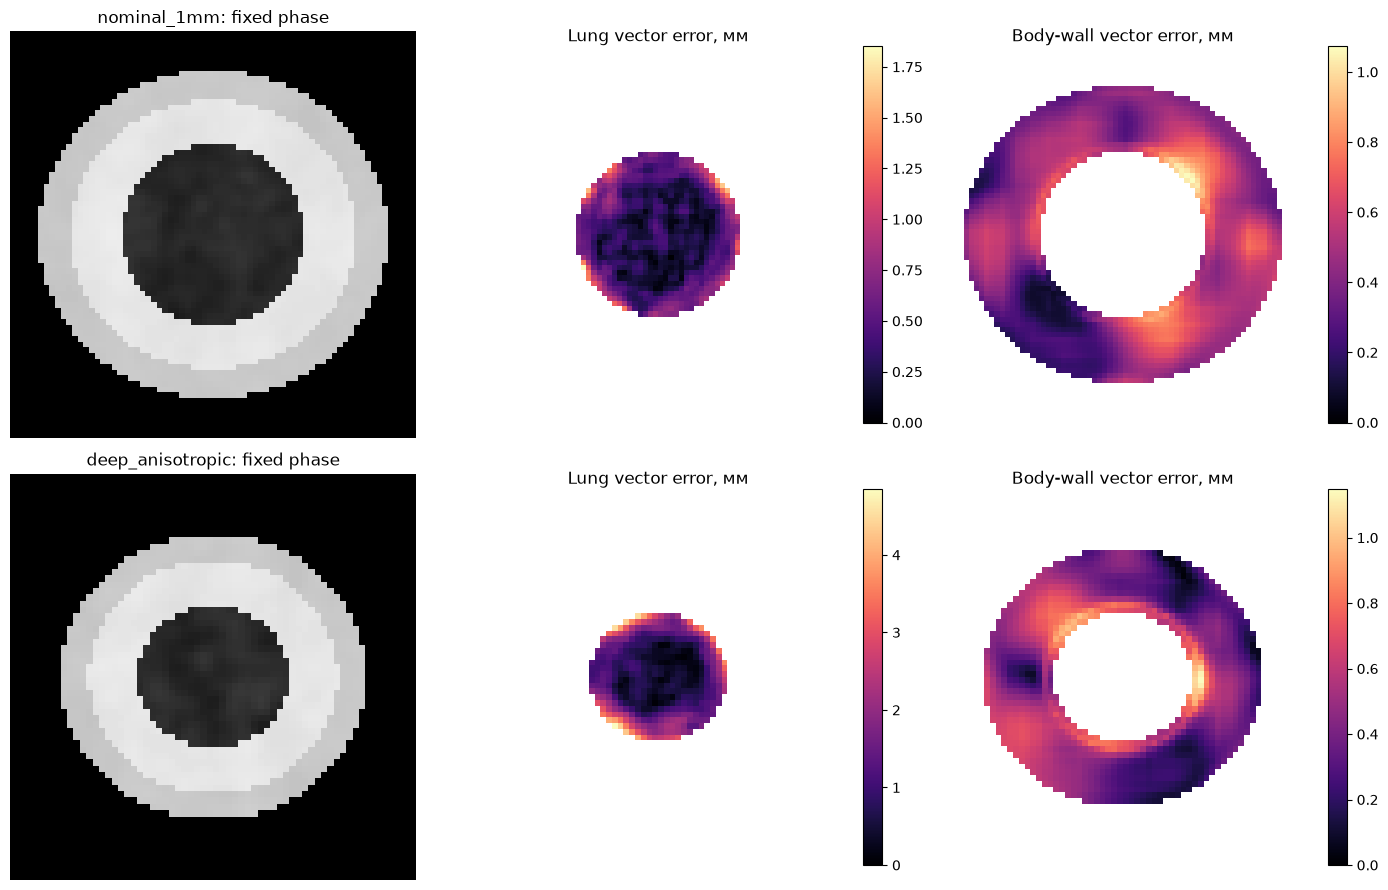

,case_id,z_region,voxel_count,mean_mm,p95_mm,maximum_mm
0,nominal_1mm,inferior,6356,0.722,1.841,4.580
1,nominal_1mm,middle,11636,0.465,0.984,2.261
2,nominal_1mm,superior,5640,0.591,1.280,3.565
3,deep_anisotropic,inferior,2116,1.601,3.659,5.890
4,deep_anisotropic,middle,3672,1.319,3.300,6.696
5,deep_anisotropic,superior,1740,1.832,4.527,7.457


In [5]:
selected_cases = ["nominal_1mm", "deep_anisotropic"]
localisation_rows = []
fig, axes = plt.subplots(len(selected_cases), 3, figsize=(14, 9))
for row, case_id in enumerate(selected_cases):
    with np.load(RESULTS / f"{case_id}.npz") as artifact:
        fixed = artifact["fixed_image"]
        lung_mask = artifact["fixed_lung_mask"].astype(bool)
        body_mask = artifact["fixed_body_mask"].astype(bool)
        lung_error = np.linalg.norm(
            artifact["estimated_lung_displacement_mm"]
            - artifact["truth_lung_displacement_mm"],
            axis=-1,
        )
        body_error = np.linalg.norm(
            artifact["estimated_body_displacement_mm"]
            - artifact["truth_body_displacement_mm"],
            axis=-1,
        )
    active_z = np.flatnonzero(np.any(lung_mask, axis=(0, 1)))
    for region, z_indices in zip(
        ["inferior", "middle", "superior"],
        np.array_split(active_z, 3),
        strict=True,
    ):
        z_band = np.zeros(lung_mask.shape[2], dtype=bool)
        z_band[z_indices] = True
        values = lung_error[lung_mask & z_band[None, None, :]]
        localisation_rows.append(
            {
                "case_id": case_id,
                "z_region": region,
                "voxel_count": len(values),
                "mean_mm": float(np.mean(values)),
                "p95_mm": float(np.percentile(values, 95)),
                "maximum_mm": float(np.max(values)),
            }
        )
    z_index = fixed.shape[2] // 2
    lung_slice = np.where(lung_mask[:, :, z_index], lung_error[:, :, z_index], np.nan).T
    wall = body_mask & ~lung_mask
    body_slice = np.where(wall[:, :, z_index], body_error[:, :, z_index], np.nan).T

    axes[row, 0].imshow(fixed[:, :, z_index].T, cmap="gray", origin="lower", vmin=-1000, vmax=150)
    axes[row, 0].set_title(f"{case_id}: fixed phase")
    im_lung = axes[row, 1].imshow(lung_slice, origin="lower", cmap="magma", vmin=0)
    axes[row, 1].set_title("Lung vector error, мм")
    fig.colorbar(im_lung, ax=axes[row, 1], fraction=0.046)
    im_body = axes[row, 2].imshow(body_slice, origin="lower", cmap="magma", vmin=0)
    axes[row, 2].set_title("Body-wall vector error, мм")
    fig.colorbar(im_body, ax=axes[row, 2], fraction=0.046)
    for ax in axes[row]:
        ax.set_axis_off()
plt.tight_layout()
plt.show()
display(pd.DataFrame(localisation_rows).round(3))

In [6]:
pass_count = int(summary["gate_pass"].sum())
case_count = len(summary)
if manifest["all_pass"]:
    verdict = (
        f"## Итог: algorithmic synthetic gate PASS ({pass_count}/{case_count})\n\n"
        "S1.0 можно заморозить и перенести на development real pairs; реальные Gate 1L/1B "
        "всё ещё обязательны."
    )
else:
    failures = summary.loc[~summary["gate_pass"], ["case_id", "gate_reasons"]]
    failure_text = "; ".join(
        f"{row.case_id}: {row.gate_reasons}" for row in failures.itertuples()
    )
    deep = summary.loc[summary["case_id"] == "deep_anisotropic"].iloc[0]
    deep_diagnosis = (
        f"В deep_anisotropic lung p95 = {deep.lung_field_p95_mm:.3f} мм при лимите "
        f"{deep.endpoint_p95_limit_mm:.3f} мм; median slip = "
        f"{deep.tangential_slip_median_mm:.3f} мм при truth "
        f"{deep.tangential_slip_truth_mm:.3f} мм."
    )
    verdict = (
        f"## Итог: algorithmic synthetic gate FAIL ({pass_count}/{case_count})\n\n"
        f"Провалы: {failure_text}. {deep_diagnosis}\n\n"
        "**Real-pair regression benchmark, карты формы лёгких и карты толщины остаются "
        "заблокированы.** Ошибка остаётся во всех трёх z-регионах deep case, а не только "
        "у исправленной оси. Поэтому нужен versioned S1.1 для большого движения; он должен "
        "улучшить внутреннее tangential lung field, не ухудшая уже прошедшие "
        "body/contact/topology проверки."
    )
display(Markdown(verdict))

## Итог: algorithmic synthetic gate FAIL (2/3)

Провалы: deep_anisotropic: lung_field_p95;tangential_slip. В deep_anisotropic lung p95 = 3.706 мм при лимите 2.250 мм; median slip = 3.213 мм при truth 6.000 мм.

**Real-pair regression benchmark, карты формы лёгких и карты толщины остаются заблокированы.** Ошибка остаётся во всех трёх z-регионах deep case, а не только у исправленной оси. Поэтому нужен versioned S1.1 для большого движения; он должен улучшить внутреннее tangential lung field, не ухудшая уже прошедшие body/contact/topology проверки.